In [1]:
import os

import pandas as pd
from tqdm import tqdm

tqdm.pandas()

# 1. Load raw data and convert to training data

In [ ]:
import gzip
import json

from tqdm import tqdm

FILE_PATHS = [
    '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_2/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_3/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_4/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_5/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/gpt-4.1_maxiter_100_N_v0.61.0-no-hint-train-eval_swebench-verified_gpt-4_1-t05-run_1/output.with_completions.jsonl.gz',
    # '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/output.with_completions.jsonl.gz',
]

# More memory efficient for large files
# Initialize lists to store the data
data = []


# Read file line by line
for FILE_PATH in FILE_PATHS:
    with gzip.open(FILE_PATH, 'rb') as f:  # Use 'rb' for gzipped files
        for i, line in tqdm(
            enumerate(f), desc=f'Processing {FILE_PATH.split("/")[-1]}'
        ):
            # Parse only the fields we need
            raw_data = json.loads(line)
            data.append(
                {
                    'resolved': raw_data['report']['resolved'],
                    'messages': raw_data['raw_completions']['messages']
                    if raw_data['raw_completions'] is not None
                    else None,
                    'git_patch': raw_data['test_result'].get('git_patch', ''),
                    'tools': raw_data['raw_completions']['tools']
                    if raw_data['raw_completions'] is not None
                    and 'tools' in raw_data['raw_completions']
                    else None,
                }
            )

# Convert to DataFrame after collecting all data
df = pd.DataFrame(data)
print(f'#total amount of data={len(df)}')
df = df[~df['messages'].isna()]
print(f'#total amount of data after removing nan={len(df)}')

Processing output.with_completions.jsonl.gz: 2119it [00:20, 105.36it/s]

#total amount of data=2119
#total amount of data after removing nan=2075


## Filter

In [4]:
def _contains_multiple_tool_calls(messages: list[dict]) -> bool:
    return any(
        message.get('tool_calls') and len(message['tool_calls']) > 1
        for message in messages
    )


df['contains_multiple_tool_calls'] = df['messages'].apply(_contains_multiple_tool_calls)
display(df.groupby(['contains_multiple_tool_calls'])['resolved'].sum())

contains_multiple_tool_calls
False    800
Name: resolved, dtype: int64

In [ ]:
import copy

# Convert function calling messages to non-function calling messages
from openhands.llm.fn_call_converter import (
    FunctionCallConversionError,
    convert_fncall_messages_to_non_fncall_messages,
    convert_from_multiple_tool_calls_to_single_tool_call_messages,
)

total_failed = 0

# Set to True for reasoning models (e.g. GLM-5 with glm45 parser)
# that split thinking into a separate 'reasoning_content' field.
# When True, reasoning_content is merged into content before conversion.
MERGE_REASONING_CONTENT = True


def _convert_messages(messages: list[dict], tools: list[dict]) -> list[dict]:
    global total_failed
    message_copy = copy.deepcopy(messages)
    for message in message_copy:
        if message['content'] is None:
            message['content'] = ''
    try:
        return convert_fncall_messages_to_non_fncall_messages(
            message_copy, tools,
            add_in_context_learning_example=False,
            merge_reasoning_content=MERGE_REASONING_CONTENT,
        )
    except FunctionCallConversionError:
        total_failed += 1
        # print(f'Failed to convert messages: {messages}\nTools: {tools}')
        # traceback.print_exc()
        return None


df['converted_messages'] = df.apply(
    lambda row: convert_from_multiple_tool_calls_to_single_tool_call_messages(
        row['messages'], ignore_final_tool_result=True
    ),
    axis=1,
)
df['nonfncall_messages'] = df.apply(
    lambda row: _convert_messages(row['converted_messages'], row['tools']), axis=1
)
print('total nan', df['nonfncall_messages'].isna().sum())
df = df[~df['nonfncall_messages'].isna()]
print(f'Total failed: {total_failed}')
print(f'MERGE_REASONING_CONTENT={MERGE_REASONING_CONTENT}')

total nan 0
Total failed: 0


## Tokenization

In [6]:
from pandarallel import pandarallel
from transformers import AutoTokenizer

os.environ['TOKENIZERS_PARALLELISM'] = 'true'
pandarallel.initialize(progress_bar=True, verbose=1, nb_workers=16)
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-7B-Instruct')


def _normalize_and_tokenize(messages):
    normalized = []
    for msg in messages:
        m = dict(msg)
        if isinstance(m.get('content'), list):
            m['content'] = '\n'.join(
                part['text'] for part in m['content'] if part.get('type') == 'text'
            )
        normalized.append(m)
    return len(tokenizer.apply_chat_template(normalized))


df['n_tokens'] = df['nonfncall_messages'].parallel_apply(_normalize_and_tokenize)

Token indices sequence length is longer than the specified maximum sequence length for this model (145765 > 131072). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (137625 > 131072). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (133839 > 131072). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (179397 > 131072). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (147118 > 131072). Running this sequence through the model will result in indexing errors


In [7]:
print(f'BEFORE: #total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'AFTER(truncated to 128k): #total={len(df_selected)}')

BEFORE: #total=2075
AFTER(truncated to 128k): #total=2069


In [8]:
df_selected['n_tokens'].describe()

count      2069.000000
mean      68103.044466
std       14733.137822
min       11773.000000
25%       58113.000000
50%       67121.000000
75%       77019.000000
max      125389.000000
Name: n_tokens, dtype: float64

,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1275.0,69934.566275,15498.237312,11773.0,59704.0,68923.0,79287.5,147118.0
True,800.0,65774.558750,14709.039989,26820.0,55933.0,64944.0,73918.5,179397.0


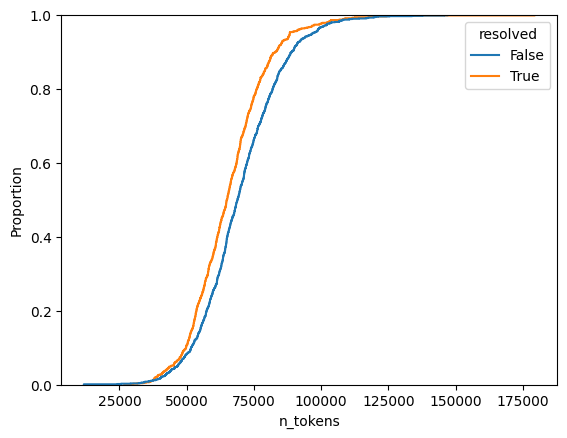

#total=2075
#selected=2069


,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1271.0,69710.641227,14995.323385,11773.0,59681.0,68831.0,79253.0,125389.0
True,798.0,65542.573935,13936.712523,26820.0,55879.0,64865.5,73836.5,124390.0


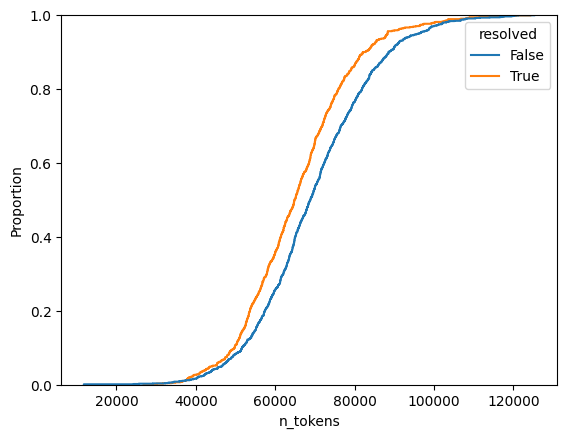

In [10]:
# ecdf of n_tokens
import matplotlib.pyplot as plt
import seaborn as sns

display(df.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df, hue='resolved')
plt.show()

print(f'#total={len(df)}')
df_selected = df[df['n_tokens'] < 131072]
print(f'#selected={len(df_selected)}')
display(df_selected.groupby(['resolved'])['n_tokens'].describe())
sns.ecdfplot(x='n_tokens', data=df_selected, hue='resolved')
plt.show()

In [11]:
df_selected[~df_selected['resolved']]['n_tokens'].describe()

count      1271.000000
mean      69710.641227
std       14995.323385
min       11773.000000
25%       59681.000000
50%       68831.000000
75%       79253.000000
max      125389.000000
Name: n_tokens, dtype: float64

In [12]:
df_selected['resolved'].value_counts()

resolved
False    1271
True      798
Name: count, dtype: int64

In [13]:
df_selected.groupby(['resolved'])['n_tokens'].describe()

,count,mean,std,min,25%,50%,75%,max
resolved,,,,,,,,
False,1271.0,69710.641227,14995.323385,11773.0,59681.0,68831.0,79253.0,125389.0
True,798.0,65542.573935,13936.712523,26820.0,55879.0,64865.5,73836.5,124390.0


In [14]:
def _normalize_to_sft_format(messages):
    """Convert messages to SWE-Gym/OpenHands-SFT-Trajectories format.

    Target: each message has only 'role' (str) and 'content' (str).
    """
    normalized = []
    for msg in messages:
        content = msg.get('content', '') or ''
        if isinstance(content, list):
            content = '\n'.join(
                part['text'] for part in content if part.get('type') == 'text'
            )
        normalized.append({'role': msg['role'], 'content': content})
    return normalized


df_selected = df_selected.copy()
df_selected['nonfncall_messages'] = df_selected['nonfncall_messages'].apply(_normalize_to_sft_format)
print('Normalized messages to SFT format (role + content strings only)')

Normalized messages to SFT format (role + content strings only)


# Save Resolved Messages for SFT

In [15]:

# save_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft"
# save_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/sft"
save_dir = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/GLM-5-FP8_maxiter_100_N_v0.61.0-no-hint-train-glm5_fp8_t05-run_1/sft"

if os.path.exists(save_dir):
    print(f'{save_dir} already exists, skipping saving.')
else:
    os.makedirs(save_dir, exist_ok=True)

df_selected[df_selected['resolved']][['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        save_dir,
        f'policy_traj_128k_swegym_resolved_{df_selected["resolved"].value_counts()[True]}i.jsonl',
    ),
    lines=True,
    orient='records',
)

df_selected[['nonfncall_messages']].rename(
    columns={'nonfncall_messages': 'messages'}
).to_json(
    os.path.join(
        save_dir,
        f'policy_traj_128k_swegym_all_{len(df_selected)}i.jsonl',
    ),
    lines=True,
    orient='records',
)

# Ablation: Reduce Reasoning in SFT Data

Randomly remove reasoning text before tool calls to ablate the effect of reasoning quality.

**Config:**
- `REMOVAL_RATIO`: probability of removing reasoning for an eligible assistant message
- `MAX_REASONING_LEN`: only remove reasoning shorter than this (longer reasoning is kept intact)
- Reasoning = text before the first `<function=...>` in an assistant message

In [1]:
import copy
import json
import os
import random

# === Configuration ===
REMOVAL_RATIO = 0.5       # probability of removing reasoning for eligible messages
MAX_REASONING_LEN = 250   # only remove reasoning shorter than this many characters
SEED = 42

# Source SFT file (Qwen3-Coder resolved trajectories)
SOURCE_PATH = (
    '/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/'
    'outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/'
    'Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/'
    'Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/'
    'sft/policy_traj_128k_swegym_resolved_634i.jsonl'
)

assert os.path.exists(SOURCE_PATH), f'Source file not found: {SOURCE_PATH}'
print(f'Source: {SOURCE_PATH}')
print(f'Config: removal_ratio={REMOVAL_RATIO}, max_reasoning_len={MAX_REASONING_LEN}, seed={SEED}')

Source: /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft/policy_traj_128k_swegym_resolved_634i.jsonl
Config: removal_ratio=0.5, max_reasoning_len=250, seed=42


In [2]:
def reduce_reasoning(messages: list[dict], ratio: float, max_len: int, rng: random.Random) -> tuple[list[dict], int, int]:
    """Remove reasoning text before tool calls with given probability.

    Args:
        messages: list of {role, content} dicts
        ratio: probability of removing reasoning for eligible messages
        max_len: only remove reasoning shorter than this
        rng: random.Random instance for reproducibility

    Returns:
        (modified_messages, n_eligible, n_removed)
    """
    result = []
    n_eligible = 0
    n_removed = 0

    for msg in messages:
        if msg['role'] != 'assistant':
            result.append(msg)
            continue

        content = msg.get('content', '') or ''
        fn_idx = content.find('<function=')

        if fn_idx <= 0:
            # No tool call, or already bare — keep as-is
            result.append(msg)
            continue

        reasoning = content[:fn_idx].strip()
        tool_call_part = content[fn_idx:]

        if len(reasoning) == 0 or len(reasoning) > max_len:
            # Already bare or reasoning too long to remove
            result.append(msg)
            continue

        n_eligible += 1
        if rng.random() < ratio:
            # Remove reasoning: emit bare tool call
            result.append({'role': msg['role'], 'content': tool_call_part})
            n_removed += 1
        else:
            result.append(msg)

    return result, n_eligible, n_removed


# Process all trajectories
rng = random.Random(SEED)
reduced_trajs = []
total_eligible = 0
total_removed = 0

with open(SOURCE_PATH) as f:
    for line in f:
        d = json.loads(line)
        msgs = d['messages']
        new_msgs, n_elig, n_rem = reduce_reasoning(msgs, REMOVAL_RATIO, MAX_REASONING_LEN, rng)
        reduced_trajs.append({'messages': new_msgs})
        total_eligible += n_elig
        total_removed += n_rem

print(f'Processed {len(reduced_trajs)} trajectories')
print(f'Eligible messages (reasoning < {MAX_REASONING_LEN} chars): {total_eligible}')
print(f'Removed reasoning: {total_removed} ({100 * total_removed / max(total_eligible, 1):.1f}%)')
print(f'Kept reasoning: {total_eligible - total_removed}')

Processed 634 trajectories
Eligible messages (reasoning < 250 chars): 23959
Removed reasoning: 11954 (49.9%)
Kept reasoning: 12005


In [3]:
# Save the reduced-reasoning version
source_basename = os.path.basename(SOURCE_PATH)
name, ext = os.path.splitext(source_basename)
output_name = f'{name}_reduce_reasoning_r{REMOVAL_RATIO}_max{MAX_REASONING_LEN}{ext}'
output_path = os.path.join(os.path.dirname(SOURCE_PATH), output_name)

with open(output_path, 'w') as f:
    for traj in reduced_trajs:
        f.write(json.dumps(traj) + '\n')

size_mb = os.path.getsize(output_path) / 1e6
print(f'Saved: {output_path}')
print(f'Size: {size_mb:.1f} MB')
print(f'Trajectories: {len(reduced_trajs)}')

Saved: /home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/sft/policy_traj_128k_swegym_resolved_634i_reduce_reasoning_r0.5_max250.jsonl
Size: 155.1 MB
Trajectories: 634


In [4]:
# Sanity check: compare original vs reduced reasoning stats
import statistics

def compute_reasoning_stats(path: str) -> dict:
    reasoning_lens = []
    bare_count = 0
    total_asst = 0
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            for m in d['messages']:
                if m['role'] != 'assistant':
                    continue
                total_asst += 1
                content = m.get('content', '') or ''
                fn_idx = content.find('<function=')
                if fn_idx >= 0:
                    reasoning = content[:fn_idx].strip()
                    reasoning_lens.append(len(reasoning))
                    if len(reasoning) == 0:
                        bare_count += 1
    return {
        'total_asst': total_asst,
        'bare_count': bare_count,
        'bare_pct': 100 * bare_count / max(total_asst, 1),
        'reasoning_median': statistics.median(reasoning_lens) if reasoning_lens else 0,
        'reasoning_mean': statistics.mean(reasoning_lens) if reasoning_lens else 0,
    }

orig_stats = compute_reasoning_stats(SOURCE_PATH)
reduced_stats = compute_reasoning_stats(output_path)

print(f"{'Metric':<25s} {'Original':>12s} {'Reduced':>12s}")
print('-' * 50)
for key in ['total_asst', 'bare_count', 'bare_pct', 'reasoning_median', 'reasoning_mean']:
    fmt = '.1f' if 'pct' in key or 'mean' in key or 'median' in key else 'd'
    print(f"{key:<25s} {orig_stats[key]:>12{fmt}} {reduced_stats[key]:>12{fmt}}")

Metric                        Original      Reduced
--------------------------------------------------
total_asst                       40722        40722
bare_count                       10967        22921
bare_pct                          26.9         56.3
reasoning_median                  73.0          0.0
reasoning_mean                   164.0        135.3
